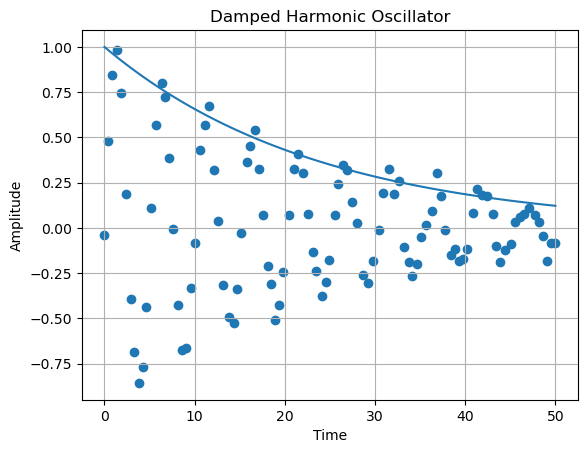

A=1.0179, damping=0.0420, omega=1.2401, phase=-0.0142, offset=0.0061


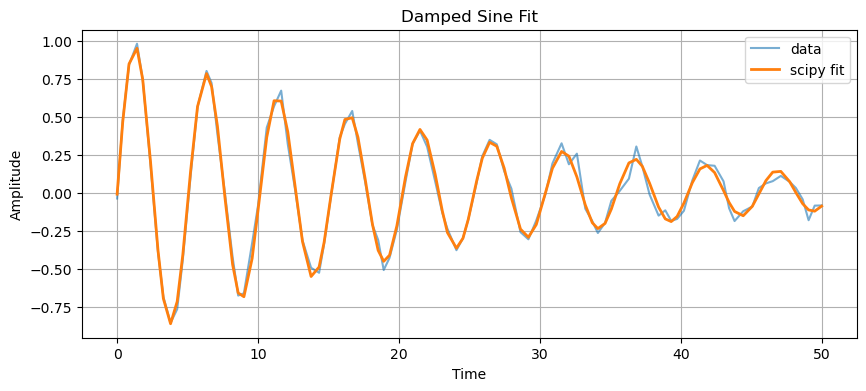

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

period = 1.24
damping = 0.042
noise = 0.042
n_samples = 1000
t_max = 50

steps = np.random.uniform(0.7, 1.3, n_samples)
x = np.cumsum(steps)
x = (x - x[0]) / (x[-1] - x[0]) * t_max
y = np.exp(-damping*x) * np.sin(period * x) + np.random.normal(0,noise,n_samples)
yy = np.exp(-damping*x)
plt.plot(x, y)
plt.plot(x,yy)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Damped Harmonic Oscillator')
plt.grid(True)
plt.show()

def damped_sine(t, A, b, w, phi, c):
  return A * np.exp(-b * t) * np.sin(w * t + phi) + c

# Initial guesses: amplitude, damping, angular frequency, phase, offset
p0 = [np.std(y) * 2, 0.04, 1.2, 0.0, np.mean(y)]
bounds = ([0, 0, 0, -2*np.pi, -np.inf], [np.inf, 1, 10, 2*np.pi, np.inf])

params, cov = curve_fit(damped_sine, x, y, p0=p0, bounds=bounds, maxfev=20000)
A_fit, b_fit, w_fit, phi_fit, c_fit = params

y_fit = damped_sine(x, *params)

print(f"A={A_fit:.4f}, damping={b_fit:.4f}, omega={w_fit:.4f}, phase={phi_fit:.4f}, offset={c_fit:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(x, y, label="data", alpha=0.6)
plt.plot(x, y_fit, label="scipy fit", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Damped Sine Fit")
plt.grid(True)
plt.legend()
plt.show()

